# Fetch Data

In [1]:
import datasets
import pandas as pd

In [ ]:
from datasets import load_dataset
import pandas as pd

column_mapping = {
    'OtabekRizayev/scam-data' : {'text': 'text', 'label': 'label'},
    'ucirvine/sms_spam': {'sms': 'text', 'label': 'label'},
    'zefang-liu/phishing-email-dataset': {'Email Text': 'text', 'label': 'label'},
    'FredZhang7/all-scam-spam': {'text': 'text', 'is_spam': 'label'},
    'bvk/SMS-spam' : {'data': 'text', 'label': 'label'},
    'BothBosu/single-agent-scam-conversations' : {'dialogue':'text', 'labels':'label'},
    'BothBosu/Scammer-Conversation' : {'conversation':'text', 'label':'label'},
    'menaattia/phone-scam-dataset' : {'dialogue':'text', 'label':'label'},
    'codesignal/sms-spam-collection' : {'message':'text', 'label':'label'}


}

# Ensure your label_mapping includes 'scam' if that dataset uses it
label_mapping = {0 : 'ham', 1 : 'fraud', 'spam' : 'fraud', 'scam': 'fraud'}

sources = [
    'OtabekRizayev/scam-data',
    'zefang-liu/phishing-email-dataset',
    'FredZhang7/all-scam-spam',
    'menaattia/phone-scam-dataset',
    'BothBosu/Scammer-Conversation',
    'BothBosu/single-agent-scam-conversations',
    'ucirvine/sms_spam',
    'bvk/SMS-spam',
    'codesignal/sms-spam-collection',
]

all_dfs = []

for source in sources:
    try:
        # Load the split (split='train' is a safe guess for most)
        ds = load_dataset(source, split='train')
        
        # Determine how many samples to take (max 1000)
        num_samples = min(5000, len(ds))
        ds = ds.shuffle(seed=42).select(range(num_samples))
        
        # Convert to DataFrame
        df = ds.to_pandas()
        
        # Standarize columns to standard 'text' and 'label' if a mapping exists
        if source in column_mapping:
            df = df.rename(columns=column_mapping[source])
            
        # Keep only the standardized columns
        df = df[['text', 'label']] if 'text' in df.columns and 'label' in df.columns else df
        
        all_dfs.append(df)
        print(f"✅ Loaded {source} ({len(df)} rows)")
        
    except Exception as e:
        print(f"❌ Failed to load {source}: {e}")

# Use ignore_index=True to prevent overlapping index issues
final_dataset = pd.concat(all_dfs, ignore_index=True)
final_dataset['label'] = final_dataset['label'].replace(label_mapping)
print("\nFinal shape:", final_dataset.shape)
final_dataset.head()



✅ Loaded OtabekRizayev/scam-data (5000 rows)
✅ Loaded zefang-liu/phishing-email-dataset (5000 rows)
✅ Loaded FredZhang7/all-scam-spam (5000 rows)
✅ Loaded menaattia/phone-scam-dataset (3200 rows)
✅ Loaded BothBosu/Scammer-Conversation (1000 rows)
✅ Loaded BothBosu/single-agent-scam-conversations (1280 rows)
✅ Loaded ucirvine/sms_spam (5000 rows)


Repo card metadata block was not found. Setting CardData to empty.


✅ Loaded bvk/SMS-spam (5000 rows)
✅ Loaded codesignal/sms-spam-collection (5000 rows)

Final shape: (35480, 4)


,text,label,Unnamed: 0,Email Type
0,Important notice: Your account verification re...,fraud,NaN,NaN
1,Important notice: Your tax refund requires urg...,fraud,NaN,NaN
2,Important notice: Your prize claim requires ur...,fraud,NaN,NaN
3,Important notice: Your tax refund requires urg...,fraud,NaN,NaN
4,Get your hands on a free laptop! immediately a...,ham,NaN,NaN


# EDA

### Drop Unused Collumn and rename label as labels

In [164]:
final_dataset = final_dataset[['text', 'label']]
final_dataset = final_dataset.set_axis(['text', 'labels'], axis=1)
final_dataset.head()

,text,labels
0,Important notice: Your account verification re...,fraud
1,Important notice: Your tax refund requires urg...,fraud
2,Important notice: Your prize claim requires ur...,fraud
3,Important notice: Your tax refund requires urg...,fraud
4,Get your hands on a free laptop! immediately a...,ham


### Check Class Distribution

In [166]:
final_dataset['labels'].value_counts()

labels
ham      21274
fraud     9206
Name: count, dtype: int64

- Data is higly imbalanced and have labelling issue

### Check Missing value and Duplication

In [167]:
final_dataset.drop_duplicates(inplace=True)
final_dataset.dropna(inplace=True)
final_dataset.isnull().sum()
final_dataset.duplicated().sum()

np.int64(0)

- No missing value

### Undersampling majority data

In [168]:
from sklearn.utils import resample
def undersample(df, target_col):
    # Separate majority and minority classes
    majority = df[df[target_col] == 'ham']
    minority = df[df[target_col] == 'fraud']
    
    # Downsample majority class
    majority_downsampled = resample(majority, 
                                  replace=False,    # sample without replacement
                                  n_samples=len(minority),     # to match minority class
                                  random_state=42)  # reproducible results
    
    # Combine minority class with downsampled majority class
    downsampled_df = pd.concat([majority_downsampled, minority])
    
    return downsampled_df

balanced_dataset = undersample(final_dataset, "labels")

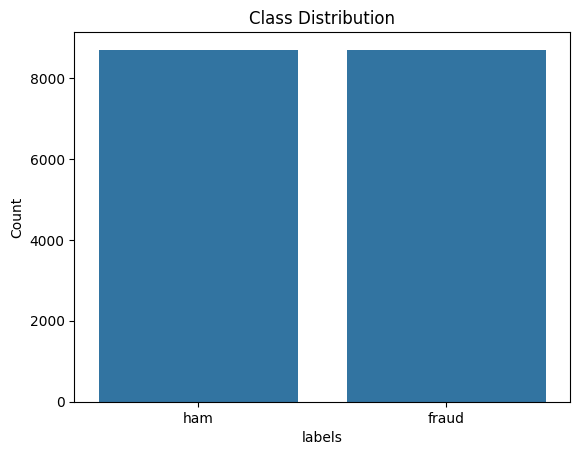

labels
ham      8698
fraud    8698
Name: count, dtype: int64

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt
def plot_class_distribution(df): 
    sns.countplot(x="labels", data=df)
    plt.title("Class Distribution")
    plt.xlabel("labels")
    plt.ylabel("Count")
    plt.show()
    return(df["labels"].value_counts())
    
plot_class_distribution(balanced_dataset)

In [170]:
balanced_dataset = balanced_dataset.sample(frac=1, random_state=42).reset_index(drop=True)
balanced_dataset.tail(20)


,text,labels
17376,Whom you waited for yesterday,ham
17377,[SACVS] CVS: spamassassin/t db_based_whitelist...,ham
17378,escalation procedures - gas logistics\n\ndesk ...,ham
17379,"['"", ow u dey.i paid 60,400thousad.i told u w...",ham
17380,"['""A boy was late 2 home. His father: """"POWER ...",ham
17381,"['""Aight, I\'m chillin in a friend\'s room so ...",ham
17382,january 25 th update\n\njeff / michelle / ken ...,ham
17383,In fact when do you leave? I think addie goes ...,ham
17384,Forgot to tell ü smth.. Can ü like number the ...,ham
17385,08714712388 between 10am-7pm Cost 10p\n,fraud


### Check for cosine Similarity Between 2 Labels

In [171]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model_url = "all-MiniLM-L6-v2"

def labels_cosine_similarity(model_url : str, data, similar_label_threshold : float):
    # 1. Load Model
    model = SentenceTransformer(model_url)
    
    # 2. Generate Embeddings
    embeddings = model.encode(data['text'].astype(str).fillna("").tolist(), show_progress_bar=True)

    # 3. Get label indices 
    idx_class_0 = data[data['labels'] == 'ham'].index
    idx_class_1 = data[data['labels'] == 'fraud'].index

    # 4. Slice embeddings
    embeddings_0 = embeddings[idx_class_0]
    embeddings_1 = embeddings[idx_class_1]

    # 5. Calculate Similarity
    cross_sim_matrix = cosine_similarity(embeddings_0, embeddings_1)
    avg_sim_matrix = np.mean(cross_sim_matrix)

    # 6. Find High Similarity (Threshold should be 0.90, not 90)
    high_sim_pairs = np.where(cross_sim_matrix > similar_label_threshold)

    # return result
    return{
        'label_similarity' : avg_sim_matrix,
        'suspected_similar_pairs' : high_sim_pairs
    }

print(labels_cosine_similarity(model_url=model_url, data=balanced_dataset, similar_label_threshold=90.0))



Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/544 [00:00<?, ?it/s]

{'label_similarity': np.float32(0.12082217), 'suspected_similar_pairs': (array([], dtype=int64), array([], dtype=int64))}


# Find Most Frequent Word in 'fraud' class

In [174]:
import spacy
from collections import Counter

# Load spaCy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def analyze_fraud_characteristics(df, label_col, n=20):
    # 1. Filter for fraud and process text
    fraud_text = " ".join(df[df[label_col] == 'fraud']['text'].astype(str))
    doc = nlp(fraud_text[:1000000]) # Stay under 1M character limit
    
    # 2. Get Lemmas (Root words) to catch characteristics like 'winning' vs 'win'
    lemmas = [
        token.lemma_.lower() for token in doc 
        if not token.is_stop and not token.is_punct and token.is_alpha
    ]
    
    # 3. Get Bigrams (2-word phrases) to find characteristic "scripts"
    bigrams = [f"{lemmas[i]} {lemmas[i+1]}" for i in range(len(lemmas)-1)]
    
    return {
        "top_themes": Counter(lemmas).most_common(n),
        "top_phrases": Counter(bigrams).most_common(n)
    }

# Run the analysis
results = analyze_fraud_characteristics(balanced_dataset, 'labels')

print("--- TOP FRAUD THEMES (Root Words) ---")
for word, count in results['top_themes']:
    print(f"{word}: {count}")

print("\n--- TOP FRAUD PHRASES (Scripts) ---")
for phrase, count in results['top_phrases']:
    print(f"{phrase}: {count}")


--- TOP FRAUD THEMES (Root Words) ---
suspect: 1047
innocent: 979
need: 724
information: 563
issue: 548
number: 538
act: 536
notice: 494
person: 490
security: 481
require: 480
account: 478
urgent: 462
avoid: 453
important: 438
attention: 436
company: 434
ref: 427
caller: 411
refund: 364

--- TOP FRAUD PHRASES (Scripts) ---
important notice: 416
require urgent: 416
urgent attention: 416
attention act: 416
avoid issue: 416
issue ref: 416
social security: 226
person b: 223
innocent okay: 206
security number: 161
helvetica san: 160
prize claim: 147
gift card: 147
notice prize: 143
claim require: 143
verification require: 142
soon possible: 142
immediately avoid: 142
notice account: 141
account verification: 141


In [176]:
# Function to show one random example of each
def show_random_examples(df, label_col):
    # Get one random row where label is 'ham'
    ham_sample = df[df[label_col] == 'ham'].sample(2).iloc[0]
    
    # Get one random row where label is 'fraud'
    fraud_sample = df[df[label_col] == 'fraud'].sample(2).iloc[0]
    
    print(f"{'='*30} HAM EXAMPLE {'='*30}")
    print(ham_sample['text'])
    print("\n")
    
    print(f"{'='*30} FRAUD EXAMPLE {'='*30}")
    print(fraud_sample['text'])
    print(f"{'='*73}")

# Call the function (using 'labels' or 'label' depending on your df)
show_random_examples(balanced_dataset, 'labels')


============================== HAM EXAMPLE ==============================
I can send you a pic if you like :)


============================== FRAUD EXAMPLE ==============================
caller: This is your utility company. Your electricity will be shut off in 30 minutes unless you pay with prepaid cards now.   receiver: I paid last week. Can you check my account again?   caller: Payment failed. To restore your service instantly, read the card numbers to me.   receiver: I’ll call the official number first, thank you.


In [177]:
# Split train test

#Shuffle the whole thing
df_shuffled = balanced_dataset.sample(frac=1, random_state=42).reset_index(drop=True)

#Calculate the cutoff point (80% for training)
split_index = int(0.85 * len(df_shuffled))

#Slice into two DataFrames
train = df_shuffled.iloc[:split_index]
test = df_shuffled.iloc[split_index:]

print(f"Train size: {len(train)}")
print(f"Test size: {len(test)}")

Train size: 14786
Test size: 2610


### EDA Findings
1. data contains 18650 samples 
2. Data Distribution {"Scam": 7328 , "Save": 11322 } -> imballance
3. Suspected mislabeled rows: 32 -> need to drop

# Save to Dataset

In [178]:
train_ds = datasets.Dataset.from_pandas(train)
test_ds = datasets.Dataset.from_pandas(test)
train_ds.save_to_disk("/Users/zhakim/Documents/ML_Project/scam_detection/experiment/data/processed/train_ds")
test_ds.save_to_disk("/Users/zhakim/Documents/ML_Project/scam_detection/experiment/data/processed/test_ds")

Saving the dataset (0/1 shards):   0%|          | 0/14786 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2610 [00:00<?, ? examples/s]